In [1]:
from collections import Counter                                                                
import optuna
from pathlib import Path

In [3]:
data_root = Path('/home/ubuntu/data/v0_6')
ref_root = Path('/home/ubuntu/data/reference_data')
hpo_output_dir = data_root / 'hpo'
study = optuna.load_study(                                                
  study_name='biojepa_v0_6_hpo_v13_phase1',
  storage=f'sqlite:///{hpo_output_dir / "biojepa_v0_6_hpo_v13_phase1"}.db'
)

In [4]:
for trial in study.trials:
    state = trial.state.name
    reason = trial.user_attrs.get('fail_reason', 'N/A')
    params = {k: trial.params.get(k, '?') for k in ['embed_dim', 'n_layer', 'heads']}
    print(f'Trial {trial.number}: {state} | D={params["embed_dim"]} L={params["n_layer"]} H={params["heads"]} | {reason}')

states = Counter(t.state.name for t in study.trials)
reasons = Counter(t.user_attrs.get('fail_reason', 'N/A') for t in study.trials if t.state.name
!= 'COMPLETE')
print(f'\nState counts: {dict(states)}')
print(f'Fail reasons: {dict(reasons)}')

Trial 0: COMPLETE | D=256 L=6 H=2 | N/A
Trial 1: COMPLETE | D=256 L=6 H=2 | N/A
Trial 2: COMPLETE | D=256 L=6 H=2 | N/A
Trial 3: COMPLETE | D=256 L=6 H=2 | N/A
Trial 4: RUNNING | D=256 L=6 H=4 | N/A

State counts: {'COMPLETE': 4, 'RUNNING': 1}
Fail reasons: {'N/A': 1}


In [5]:
for trial in study.trials[:]:
    print(f'Trial {trial.number}: user_attrs={trial.user_attrs}, system_attrs={trial.system_attrs}')

Trial 0: user_attrs={'eval_10000': {'pert_auroc': 0.542, 'eff_dim_90': 7, 'dead_dims': 0, 'recon_pearson': 0.929, 'invariance_ratio': 0.2273, 'kegg_silhouette': -0.1031, 'cell_type_acc': 0.9089, 'essential_auroc': 0.608, 'consistency_ratio': 1.0528}, 'eval_15000': {'pert_auroc': 0.5561, 'eff_dim_90': 6, 'dead_dims': 0, 'recon_pearson': 0.9292, 'invariance_ratio': 0.3571, 'kegg_silhouette': -0.0901, 'essential_auroc': 0.5881, 'consistency_ratio': 1.0046}, 'eval_20000': {'pert_auroc': 0.5074, 'eff_dim_90': 7, 'dead_dims': 0, 'recon_pearson': 0.9471, 'invariance_ratio': 0.5455, 'kegg_silhouette': -0.0993, 'cell_type_acc': 0.961, 'essential_auroc': 0.5904, 'consistency_ratio': 1.0162}, 'eval_25000': {'pert_auroc': 0.5608, 'eff_dim_90': 8, 'dead_dims': 0, 'recon_pearson': 0.9508, 'invariance_ratio': 0.4333, 'kegg_silhouette': -0.0924, 'essential_auroc': 0.6049, 'consistency_ratio': 1.0004}, 'eval_30000': {'pert_auroc': 0.5239, 'eff_dim_90': 6, 'dead_dims': 0, 'recon_pearson': 0.9483, 'invar

In [6]:
importances = optuna.importance.get_param_importances(study)                     
importances     

{'lr': np.float64(0.2787072957168344),
 'ema_momentum': np.float64(0.216088213046053),
 'vicreg_weight': np.float64(0.21536581735213398),
 'mask_ratio': np.float64(0.1428634248900837),
 'gaussian_scale': np.float64(0.09666127323128687),
 'film_linear_multiple': np.float64(0.05031397576360801),
 'n_layer': np.float64(0.0),
 'embed_dim': np.float64(0.0),
 'heads': np.float64(0.0)}

/tmp/ipykernel_104198/2210069751.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_slice(study)
/home/ubuntu/miniconda3/envs/general/lib/python3.14/site-packages/optuna/visualization/matplotlib/_slice.py:146: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(xlim[0], xlim[1])


array([<Axes: xlabel='ema_momentum', ylabel='Objective Value'>,
       <Axes: xlabel='embed_dim'>, <Axes: xlabel='film_linear_multiple'>,
       <Axes: xlabel='gaussian_scale'>, <Axes: xlabel='heads'>,
       <Axes: xlabel='lr'>, <Axes: xlabel='mask_ratio'>,
       <Axes: xlabel='n_layer'>, <Axes: xlabel='vicreg_weight'>],
      dtype=object)

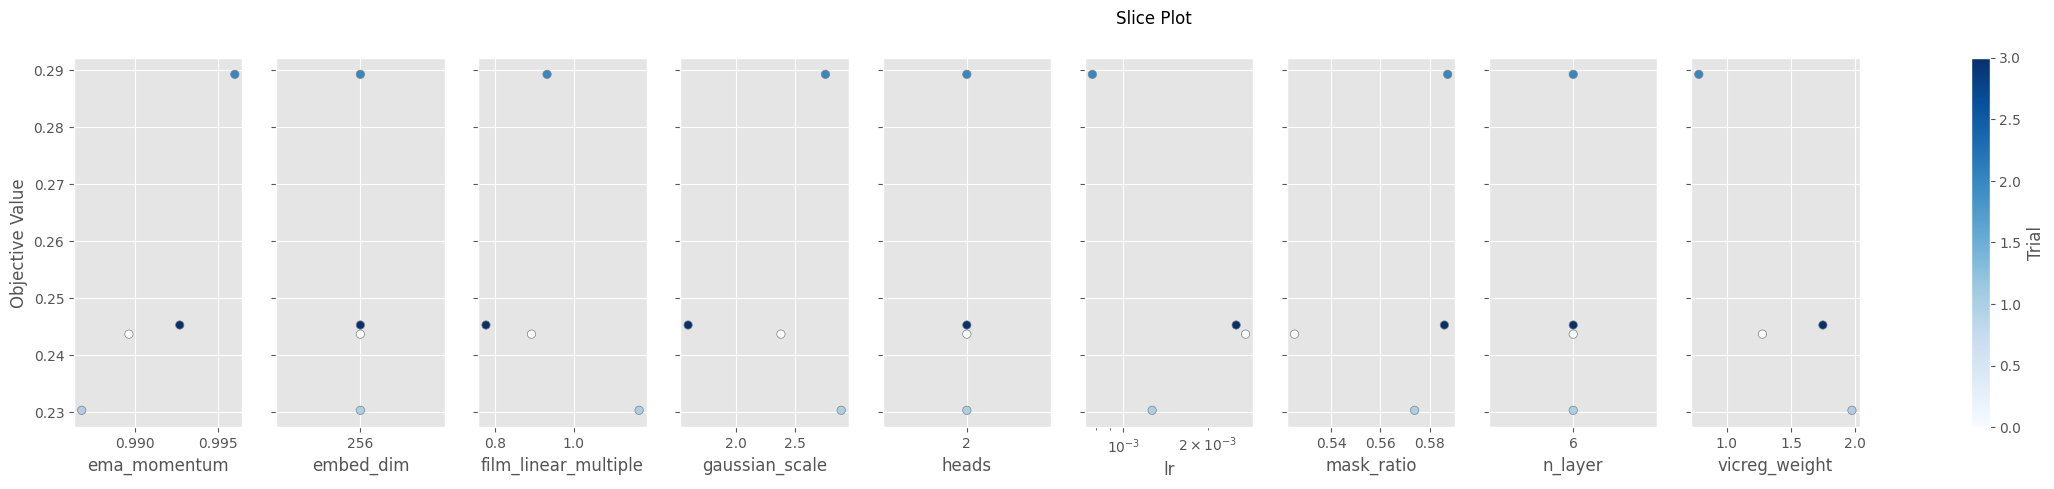

In [7]:
optuna.visualization.matplotlib.plot_slice(study)   

In [9]:
df = study.trials_dataframe()
completed = df[df['value'].notna()]
k = max(3, len(completed) // 3)
top_k = completed.nlargest(k, 'value')

continuous_params = [c for c in completed.columns if c.startswith('params_') and
completed[c].dtype == 'float64']
centroid = top_k[continuous_params].median()
centroid_std = top_k[continuous_params].std()

top_k[['number', 'value'] + continuous_params]

,number,value,params_ema_momentum,params_film_linear_multiple,params_gaussian_scale,params_lr,params_mask_ratio,params_vicreg_weight
2,2,0.289260,0.996022,0.932251,2.752774,0.000778,0.587247,0.781713
3,3,0.245225,0.992710,0.777876,1.597586,0.002519,0.585914,1.748556
0,0,0.243621,0.989655,0.892914,2.377951,0.002720,0.525157,1.277589


In [7]:
!nvidia-smi

Mon Feb  9 18:45:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GH200 480GB             On  |   00000000:DD:00.0 Off |                    0 |
| N/A   66C    P0            518W /  700W |   20480MiB /  97871MiB |     99%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----